In [9]:
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [74]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb

In [ ]:
e1 = []; e2 = []; j1 = []; j2 = []; r1 = []; r2 = []; p1 = []; p2 = []; 

In [40]:
its   = [60]
lls   = [14]
tnets = ['rbm']

for it in its:
    for ll in lls:
        for tnet in tnets :
            print(ll,',',it)
            trained_params_list              = [];  parameters_list = []; iii = []; 
            tFe = 0;  net = tnet; 
            trained_params_list              = []; parameters_list = [];iii = []; 
            #exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
            #calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
            g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

            print(it)
            tFe = 1; net = tnet; 
            trained_params_list              = [];  parameters_list = []; iii = []; 
            #exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
            #calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
            g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

            l = ll; l_info = [];  l_info = upper(tnet);  
            str_nets = '1_' + upper(tnet)
            x_pos  = 0.2 ;  y_pos = 0.94; index = 2

            plot2(e_path1,e_path2,
                  j_out1,r_out1,
                  j_out2,r_out2,
                  l,it,l_info,
                  x_pos, y_pos, str_nets)
            
            plot_m_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
            
            plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)

            e1.append(e_path1); e2.append(e_path2)
            j1.append(j_out1); j2.append(j_out2)   
            r1.append(r_out1); r2.append(r_out2)           
            p1.append(paths1); p2.append(paths2)
            

            #plotpca(paths1, paths2,  0, -1, ll,it, str_nets)
            #plotpca3(paths1, paths2,  0, -1, ll,it, str_nets) 

            
            #plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

14 , 60
rbm


  0%|                                                              | 0/60 [00:00<?, ?it/s]

60
rbm


  0%|                                                              | 0/60 [00:00<?, ?it/s]

fig/mf/EGS_L_14_14_IT_60_RBM.png
Figuras salvas em: fig/mf/PRSN_14_14_IT_60_1_RBM_0_ferro.png e fig/mf/PRSN_14_14_IT_60_1_RBM_0_antiferro.png
Figura salva em: fig/mf/PRSN_14_14_IT_60_1_RBM_0_NN.png


In [ ]:
#plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,x_pos, y_pos, str_nets)

In [80]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
plot_m_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)

Figuras salvas em: fig/mf/PRSN_14_14_IT_60_1_RBM_0_ferro.png e fig/mf/PRSN_14_14_IT_60_1_RBM_0_antiferro.png
Figura salva em: fig/mf/PRSN_14_14_IT_60_1_RBM_0_NN_BB.png


In [69]:
p1

[['dataf/rbm_14_0_40_1_bias_real.csv',
  'dataf/rbm_14_0_40_1_bias_img.csv',
  'dataf/rbm_14_0_40_1_kernel_real.csv',
  'dataf/rbm_14_0_40_1_kernel_img.csv'],
 ['dataf/rbm_14_0_60_1_bias_real.csv',
  'dataf/rbm_14_0_60_1_bias_img.csv',
  'dataf/rbm_14_0_60_1_kernel_real.csv',
  'dataf/rbm_14_0_60_1_kernel_img.csv']]

In [62]:
df1 = pd.read_csv(p1[0][0])

In [63]:
df1.shape

(40, 15)

In [64]:
correlation = df1.corr(


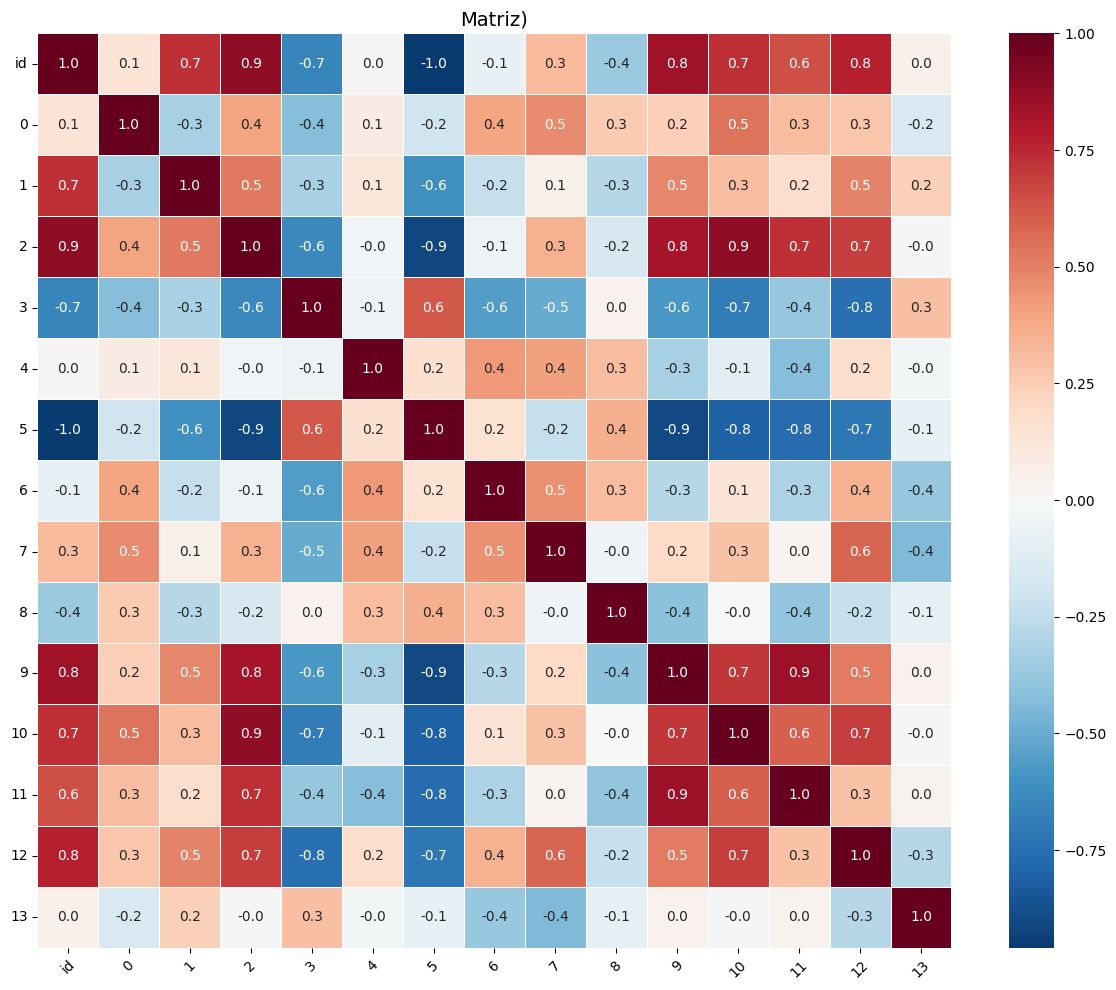

In [67]:
correlation_sample = correlation

plt.figure(figsize=(12, 10))
plot = sns.heatmap(correlation_sample, 
                   annot=True, 
                   fmt=".1f", 
                   linewidths=.6,
                   cmap='RdBu_r',
                   center=0)
plt.title('Matriz)', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

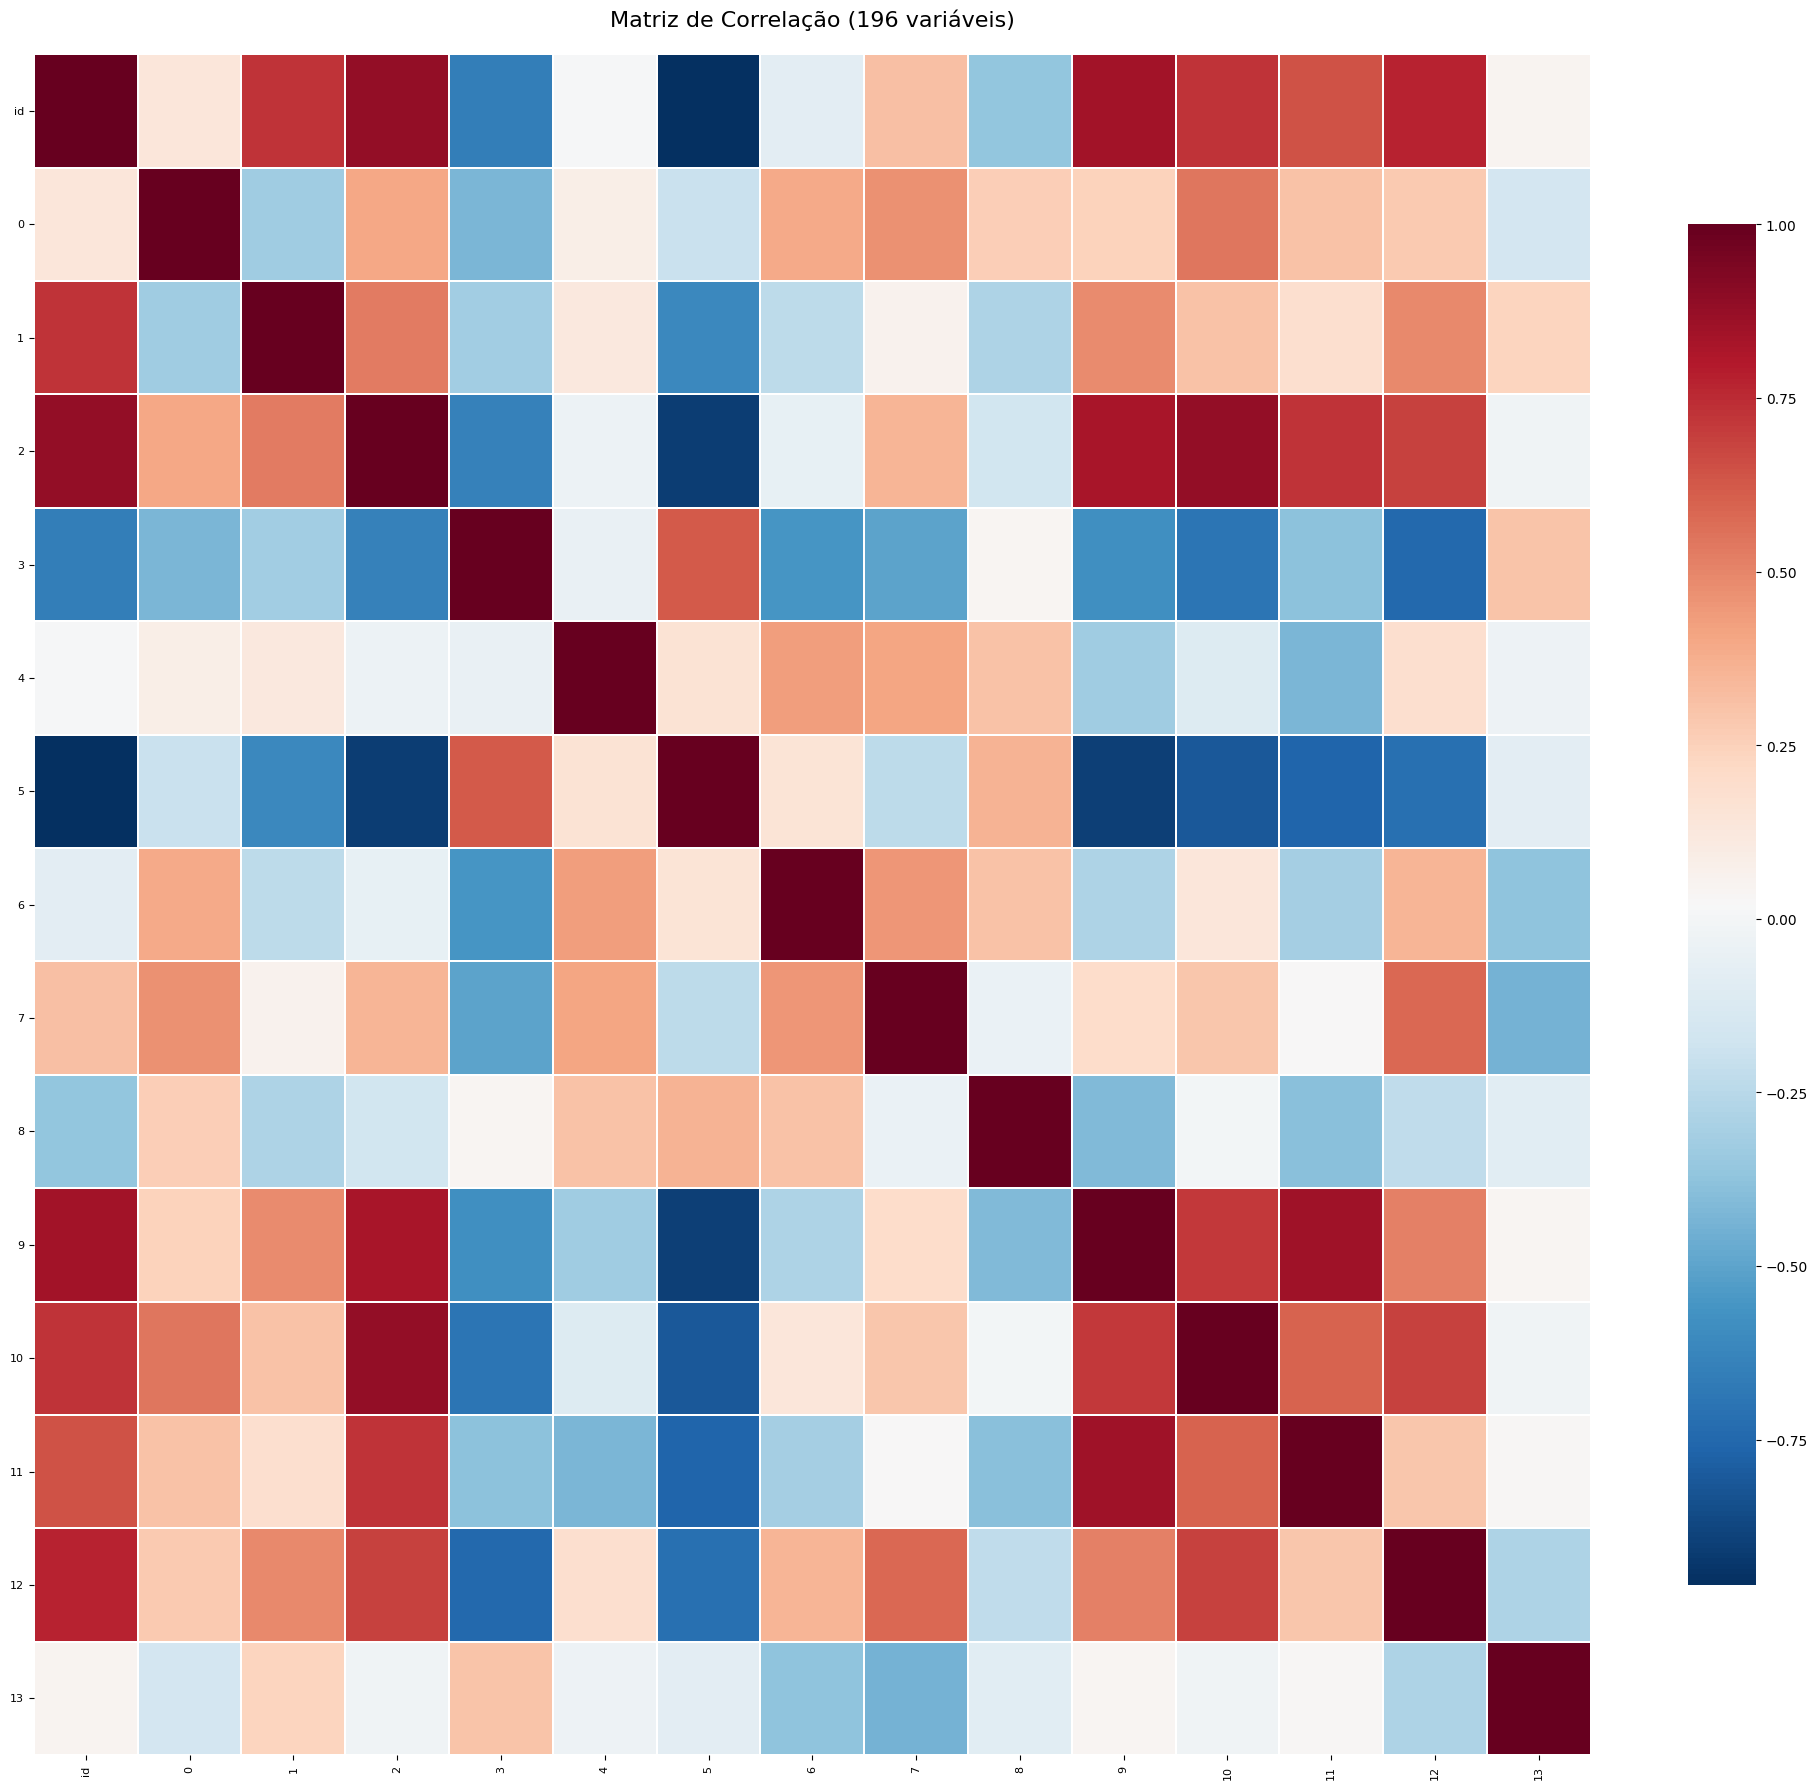

In [65]:
plt.figure(figsize=(20, 18))  # Aumente o tamanho da figura
plot = sns.heatmap(correlation, 
                   annot=False,  # Remove annotations para muitas colunas
                   fmt=".1f", 
                   linewidths=.1,  # Linhas mais finas
                   cmap='RdBu_r',  # Colormap alternativo
                   cbar_kws={'shrink': 0.8})  # Barra de cores menor
plt.title('Matriz de Correlação (196 variáveis)', fontsize=16, pad=20)
plt.xticks(rotation=90, fontsize=8)  # Rotações e tamanho menor
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [43]:
paths1 = p1[0]; paths2 = p2[0]; 
df1 = pd.read_csv(paths1[2])

In [44]:
df1 = df1.iloc[:, 1:]  

In [45]:
df1.head()

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,193,194,195
0,-0.010001,-0.008626,-0.007623,-0.011572,-0.003109,-0.019943,0.008313,0.001567,0.001985,-0.005874,...,-0.001939,0.009377,-0.007794,-0.016966,-0.009459,-0.005873,0.016750,0.006264,0.000146,-0.013695
1,0.052879,-0.005614,0.014709,0.032690,-0.075679,0.003650,-0.005566,-0.079177,-0.017608,-0.002890,...,0.030084,0.002035,0.041889,0.008122,-0.018856,-0.003717,0.049066,-0.046320,-0.042791,0.047599
2,0.010942,-0.057191,0.027806,0.017994,-0.065671,-0.031289,0.028486,-0.087826,-0.003108,-0.032845,...,0.019592,0.014120,0.069802,-0.062916,-0.015849,-0.014193,0.172358,-0.054681,-0.048611,-0.004129
3,0.005931,-0.080078,-0.014695,0.020060,-0.095414,-0.074532,0.059457,-0.138260,0.001490,-0.049042,...,0.018127,0.021062,0.068744,-0.077466,-0.038782,-0.040736,0.258777,-0.054976,-0.070740,0.002946
4,0.011998,-0.117788,0.002982,0.045945,-0.117658,-0.119082,0.058602,-0.183444,-0.009916,-0.067711,...,0.021664,0.031541,0.098305,-0.093044,-0.053086,-0.048080,0.336035,-0.073681,-0.089067,0.006997


In [50]:
len(df1.columns)

196

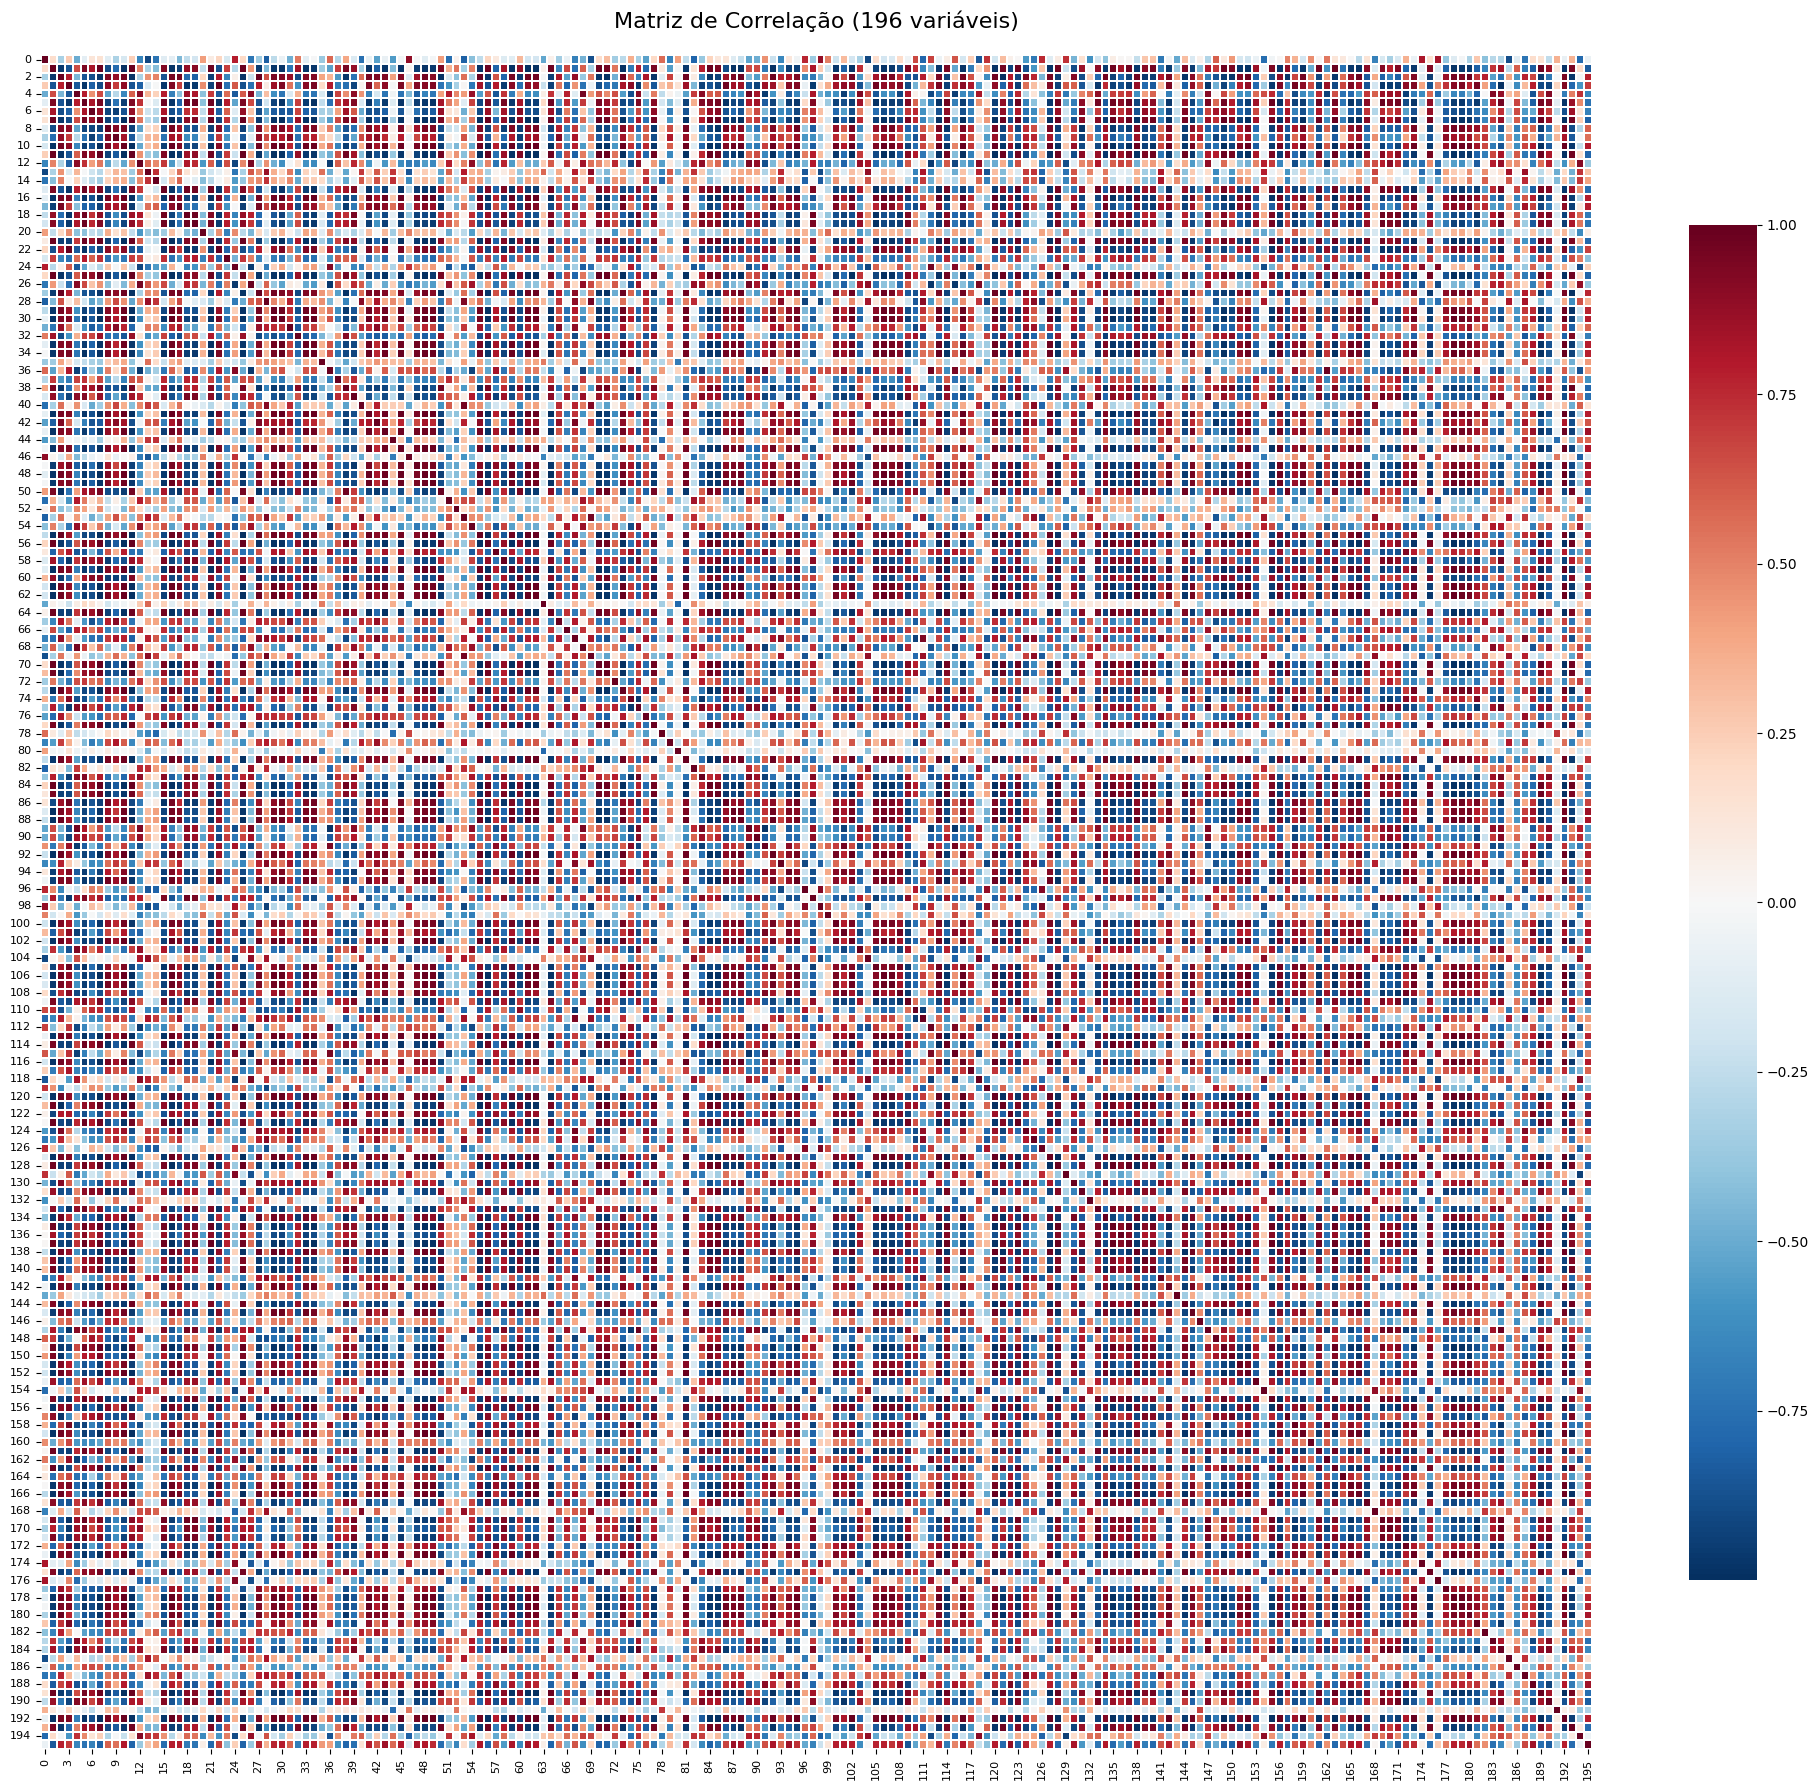

In [51]:
plt.figure(figsize=(20, 18))  # Aumente o tamanho da figura
plot = sns.heatmap(correlation, 
                   annot=False,  # Remove annotations para muitas colunas
                   fmt=".1f", 
                   linewidths=.1,  # Linhas mais finas
                   cmap='RdBu_r',  # Colormap alternativo
                   cbar_kws={'shrink': 0.8})  # Barra de cores menor
plt.title('Matriz de Correlação (196 variáveis)', fontsize=16, pad=20)
plt.xticks(rotation=90, fontsize=8)  # Rotações e tamanho menor
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

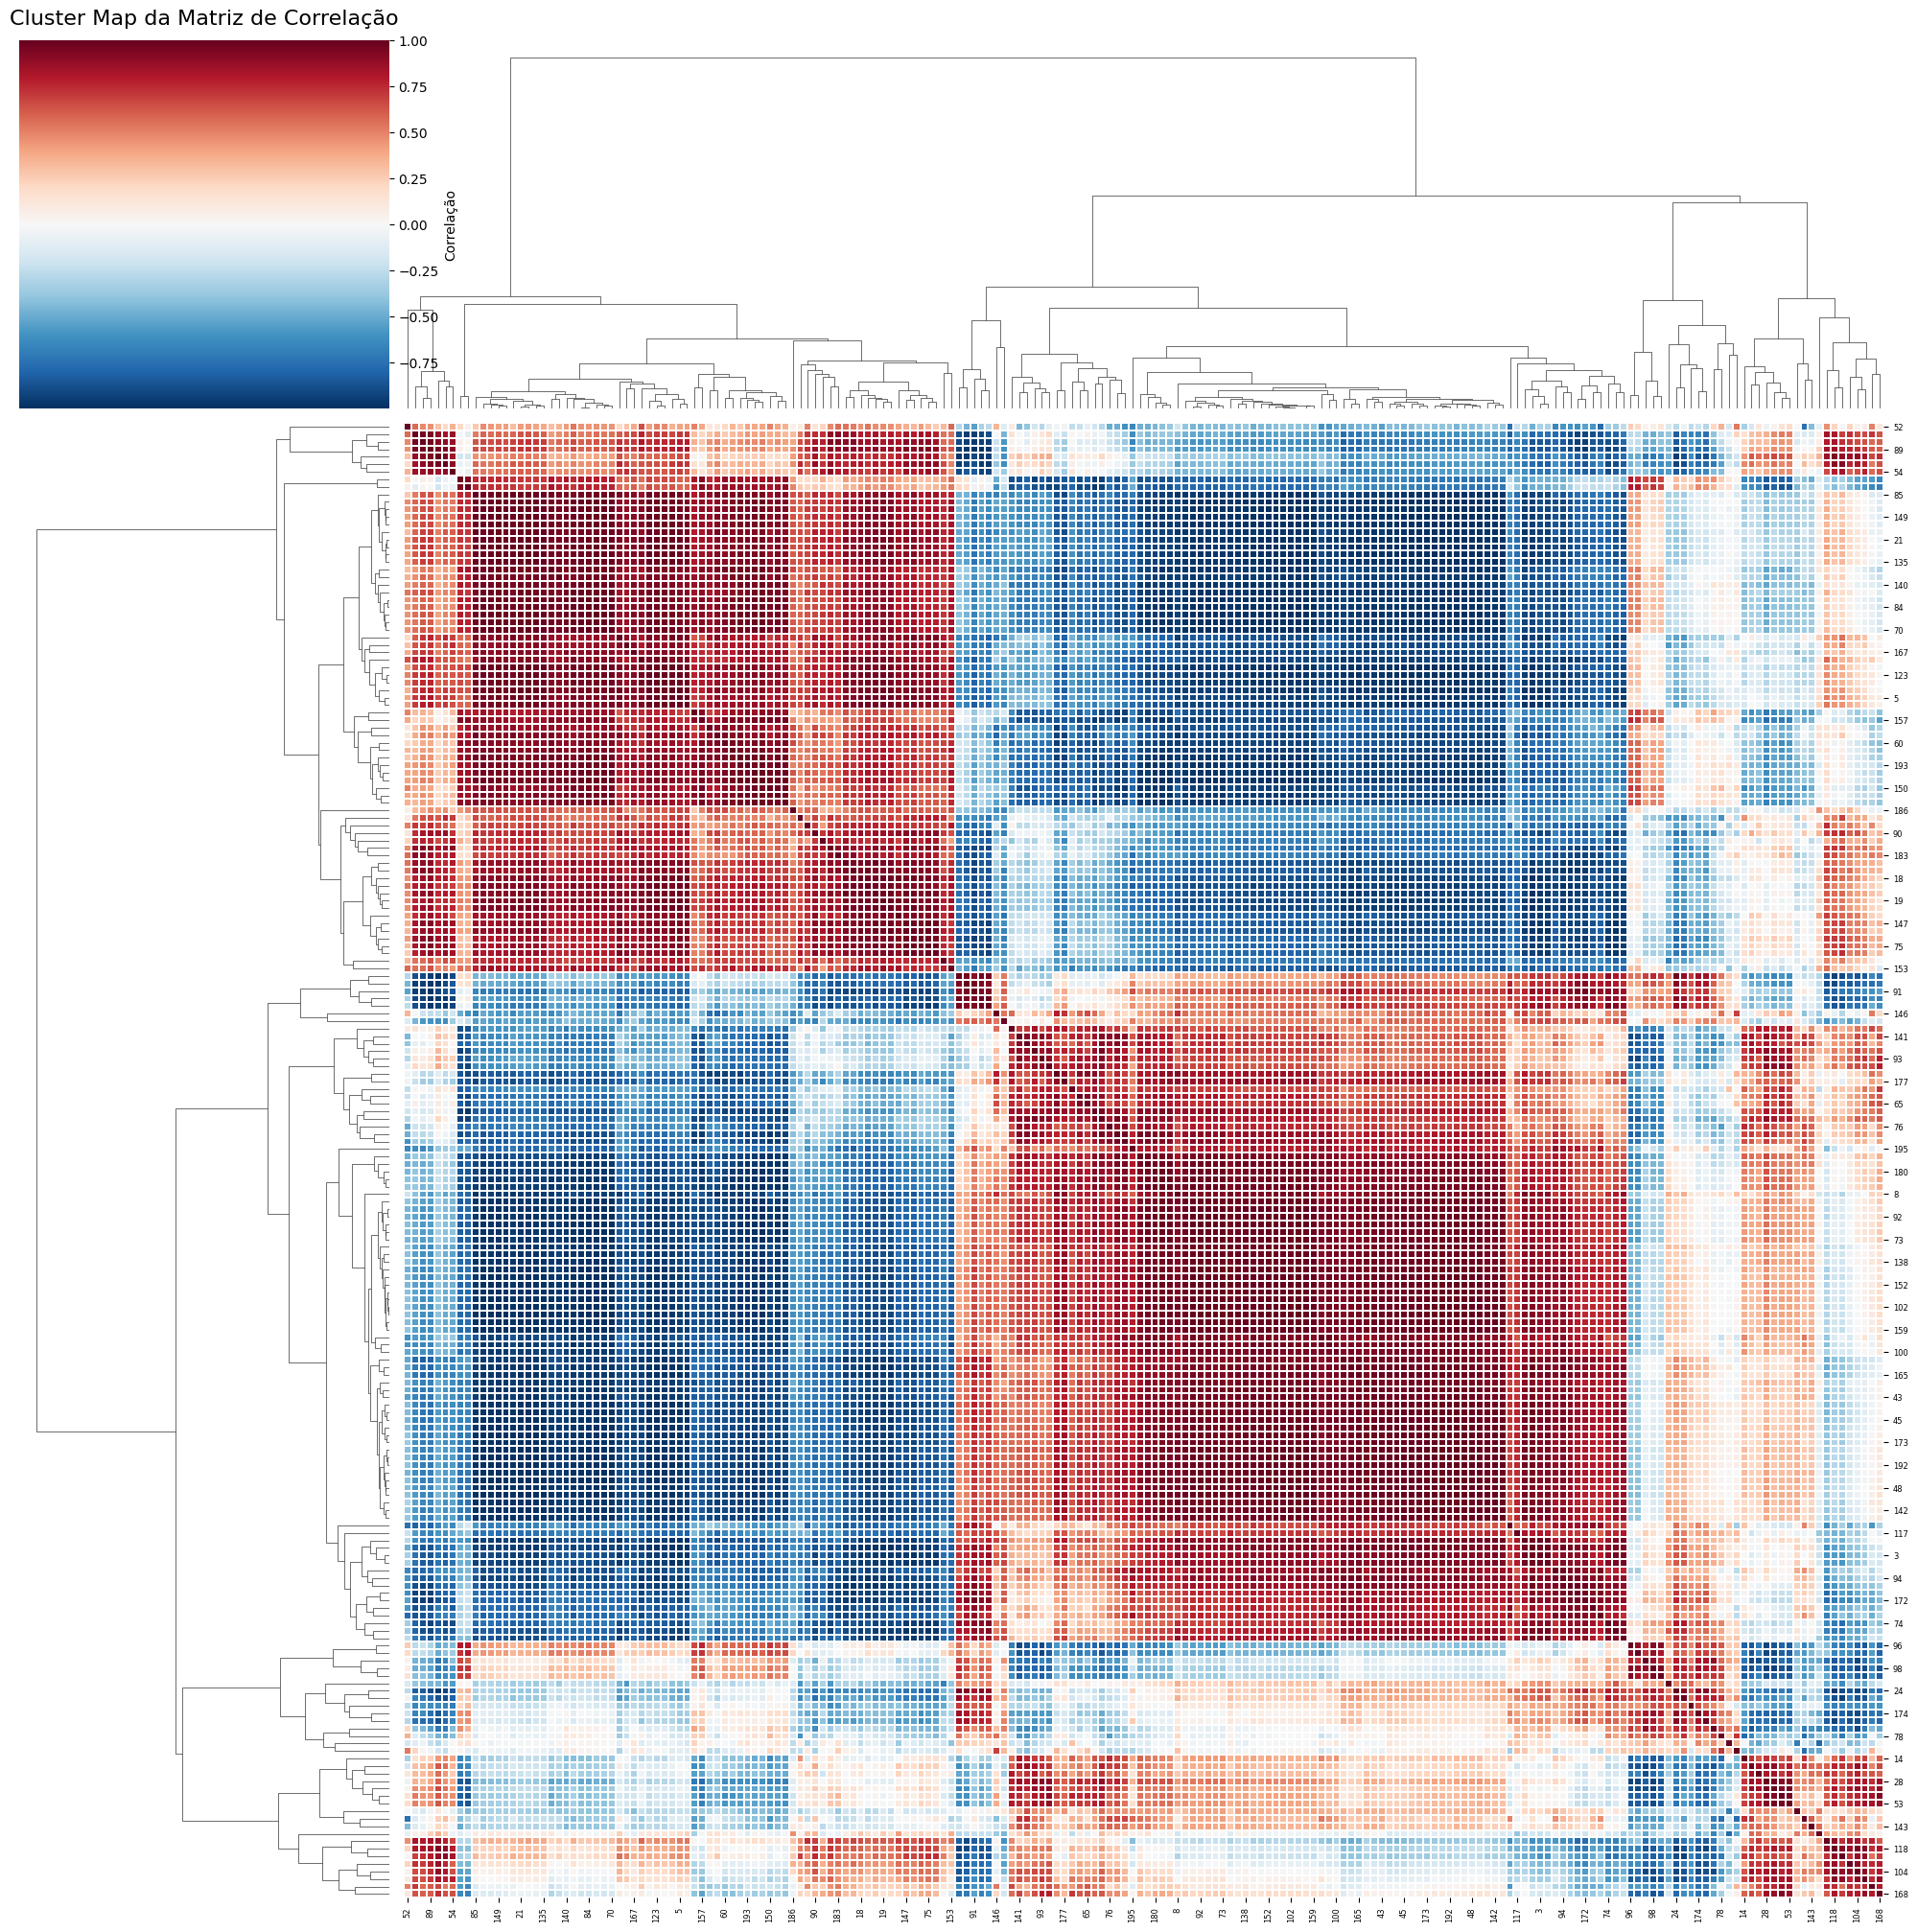

In [52]:
# Usando clustermap para agrupar variáveis correlacionadas
g = sns.clustermap(correlation, 
                   annot=False,
                   figsize=(20, 20),
                   cmap='RdBu_r',
                   center=0,
                   linewidths=.1,
                   cbar_kws={'label': 'Correlação'})
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=6)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=6)
plt.title('Cluster Map da Matriz de Correlação', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

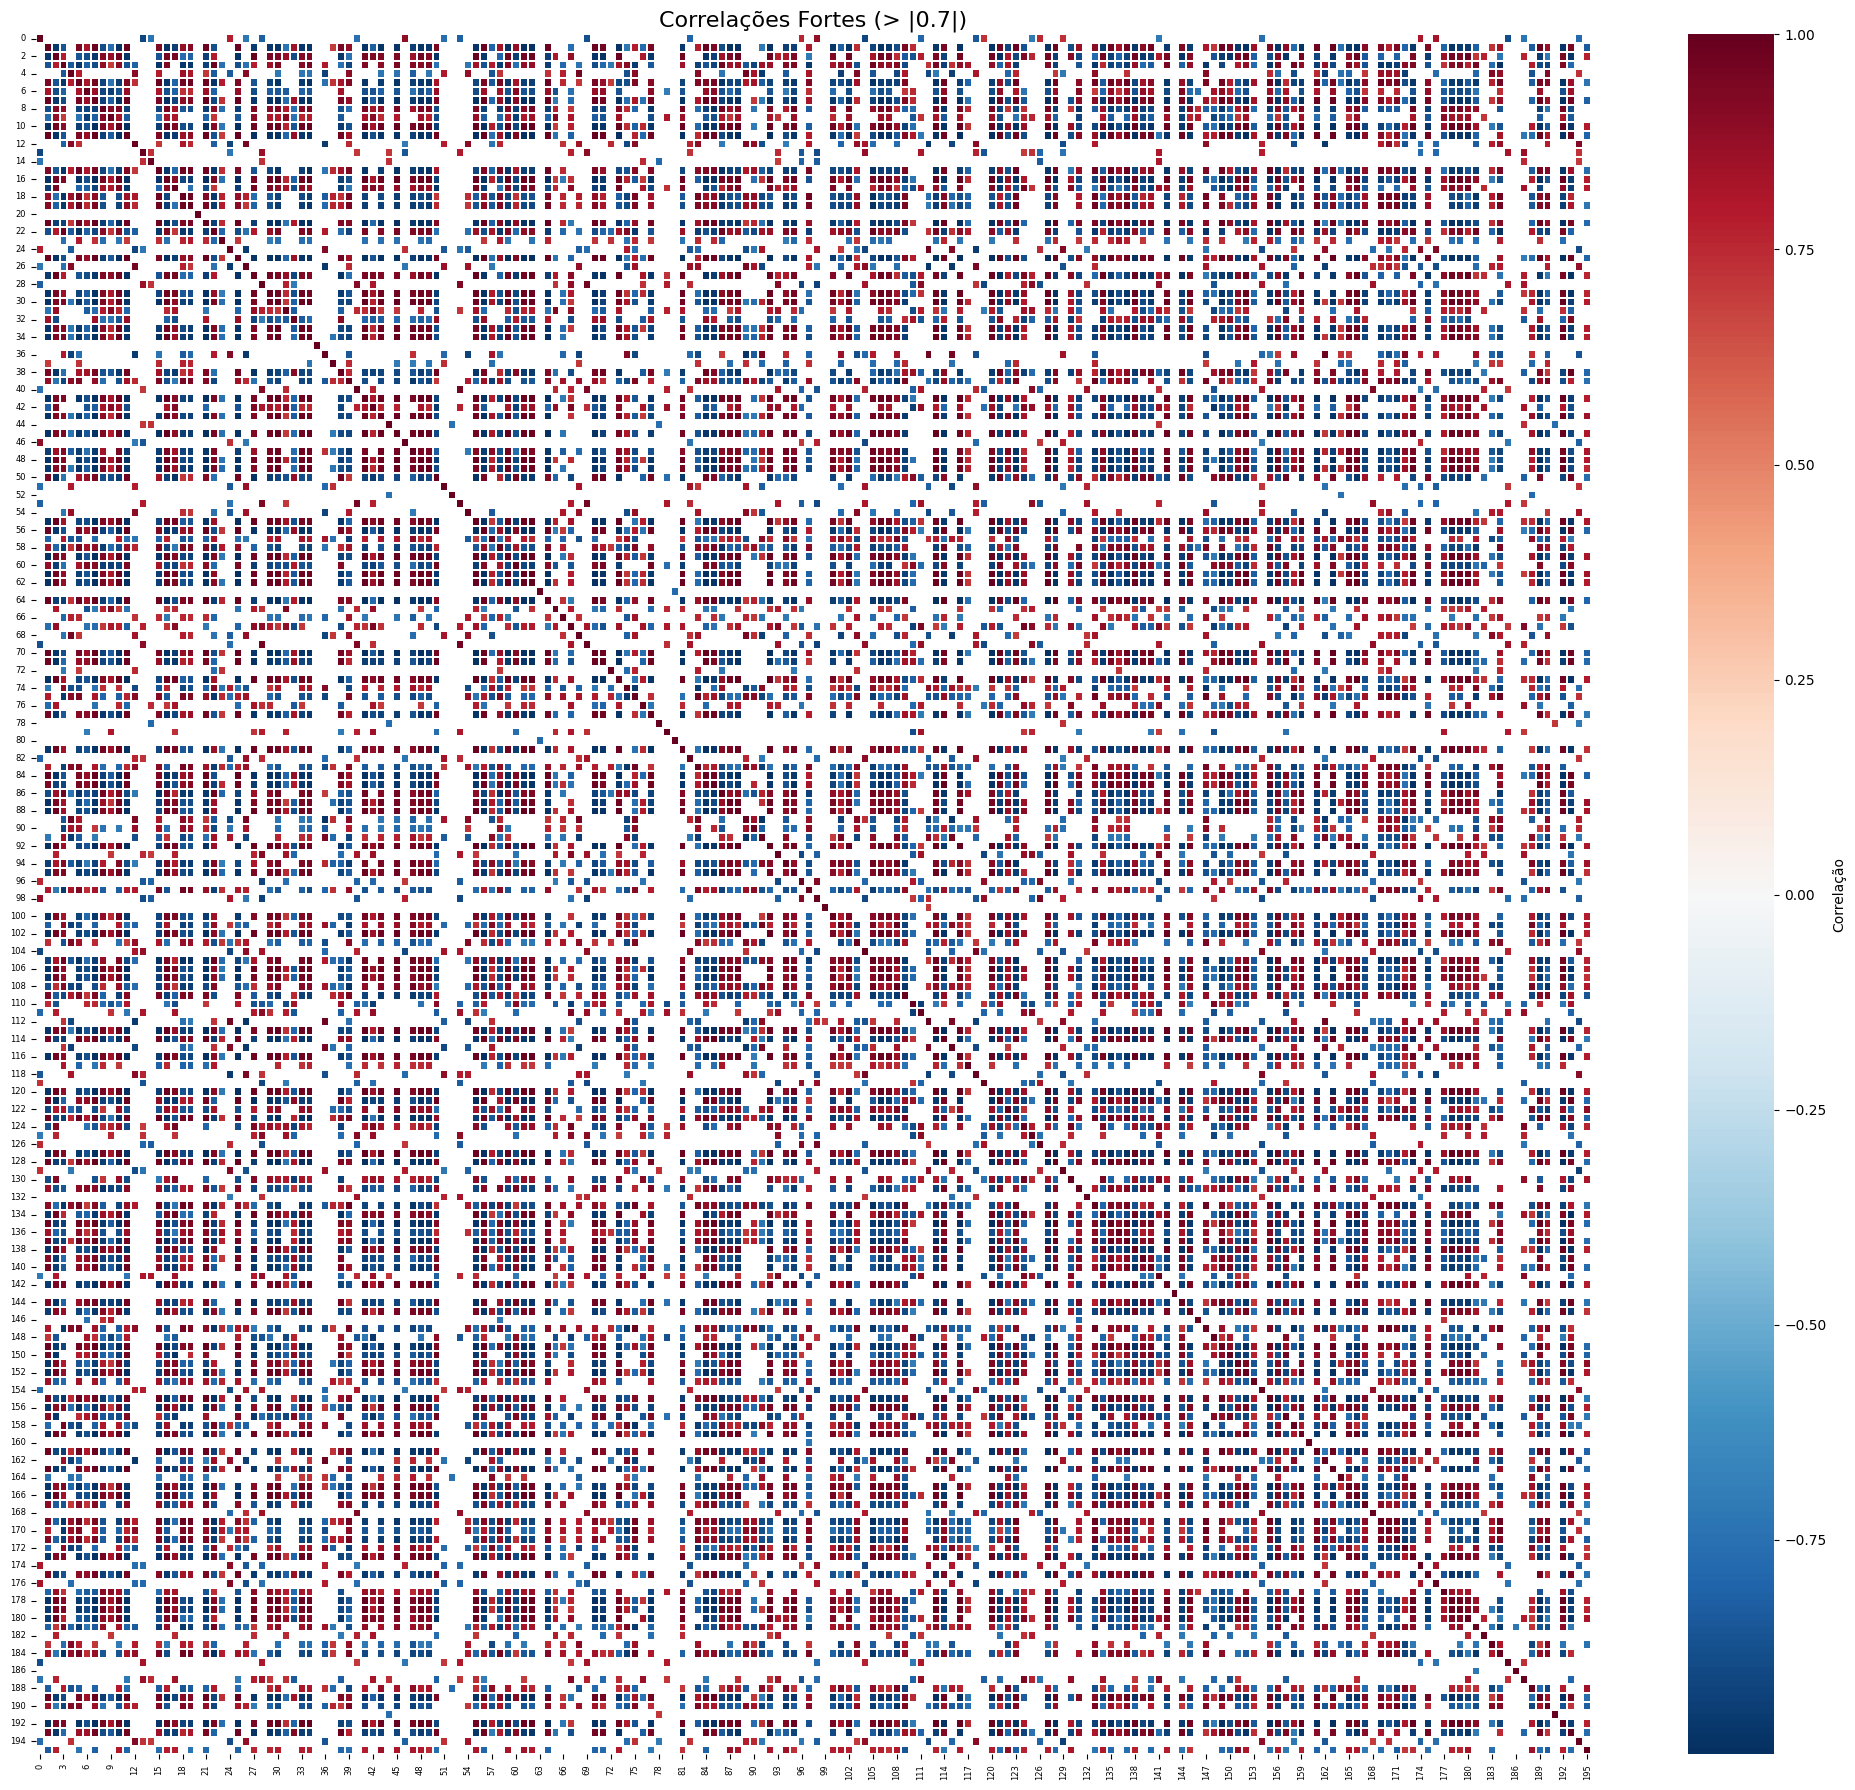

In [53]:
# Máscara para mostrar apenas correlações significativas
mask = (correlation.abs() < 0.7)  # Mostra apenas correlações > |0.7|

plt.figure(figsize=(20, 18))
plot = sns.heatmap(correlation, 
                   annot=False,
                   mask=mask,  # Aplica a máscara
                   cmap='RdBu_r',
                   linewidths=.1,
                   cbar_kws={'label': 'Correlação'})
plt.title('Correlações Fortes (> |0.7|)', fontsize=16)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

In [48]:
import pandas as pd
import seaborn as sn

In [46]:
correlation = df1.corr()

<Axes: >

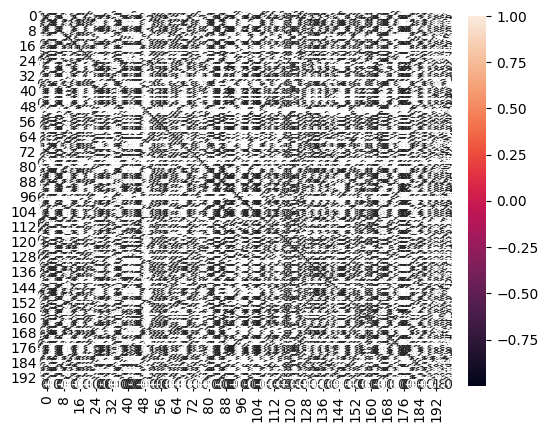

In [49]:
plot = sn.heatmap(correlation, annot = True, fmt=".1f", linewidths=.6)
plot

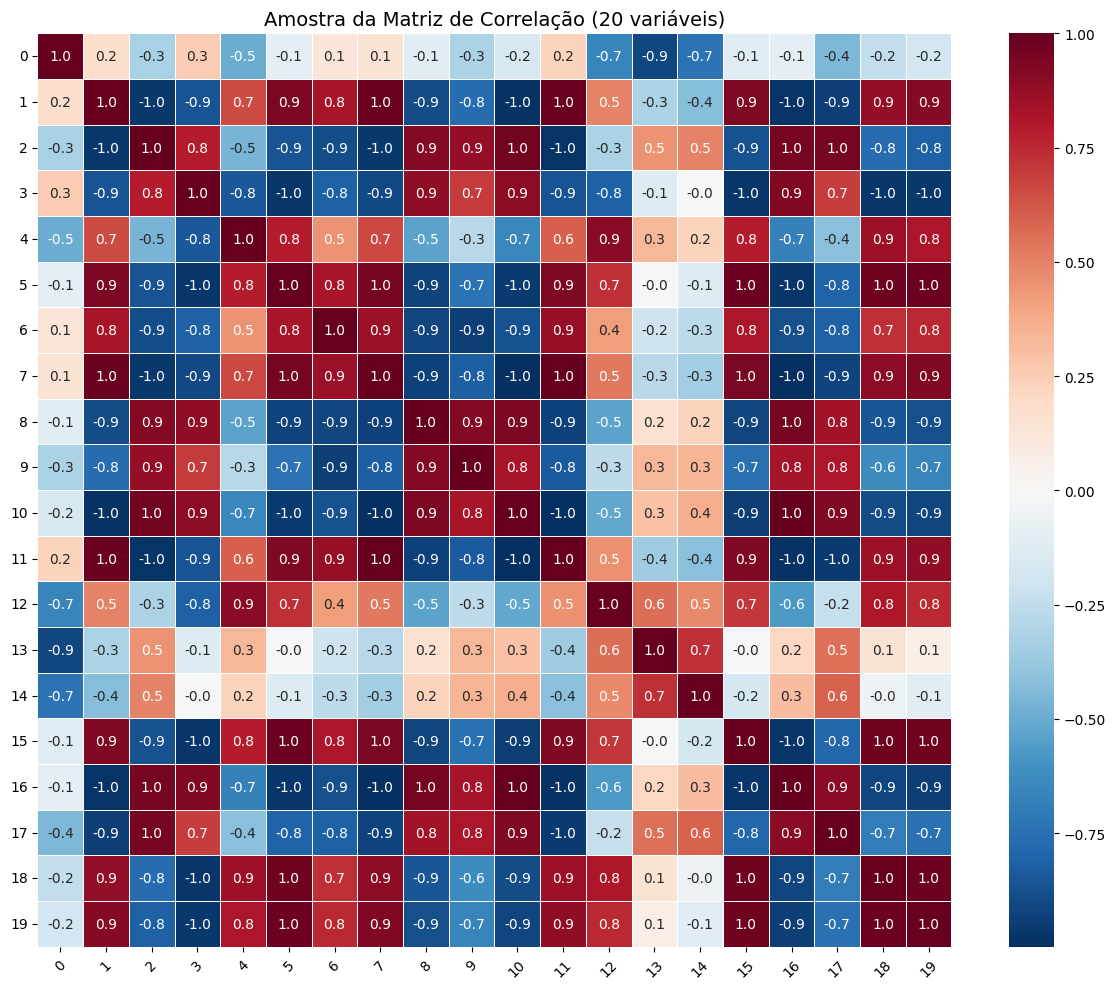

In [54]:
# Seleciona apenas algumas variáveis para visualização
sample_cols = correlation.columns[:20]  # Primeiras 20 variáveis
correlation_sample = correlation.loc[sample_cols, sample_cols]

plt.figure(figsize=(12, 10))
plot = sns.heatmap(correlation_sample, 
                   annot=True, 
                   fmt=".1f", 
                   linewidths=.6,
                   cmap='RdBu_r',
                   center=0)
plt.title('Amostra da Matriz de Correlação (20 variáveis)', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
paths1 = p1[0]; paths2 = p2[0]; 
df1 = pd.read_csv(paths1[2])
df2 = pd.read_csv(paths2[2])
df1 = df1.iloc[:, 1:]  
df2 = df2.iloc[:, 1:]

In [5]:
len(df1.columns)

196

In [6]:
df1.shape

(40, 196)

In [7]:
# Transpondo o DataFrame
df11 = df1.T

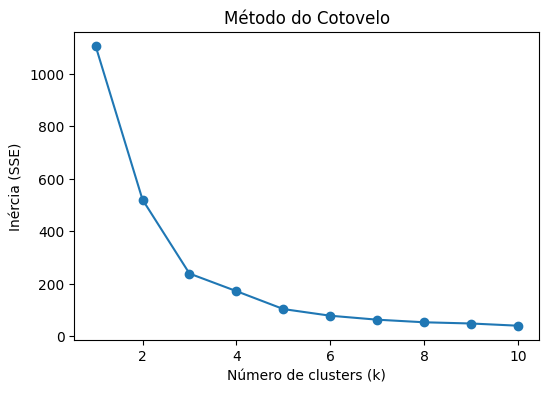

In [25]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Supondo que df seja o seu DataFrame
X = df11.values  # transforma em array NumPy

# Testar k de 1 até, por exemplo, 10
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.figure(figsize=(6,4))
plt.plot(K, inertias, "o-", color="tab:blue")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (SSE)")
plt.title("Método do Cotovelo")
plt.show()


In [27]:
+


k=2, silhouette=0.488
k=3, silhouette=0.498
k=4, silhouette=0.423
k=5, silhouette=0.422
k=6, silhouette=0.389
k=7, silhouette=0.335
k=8, silhouette=0.281
k=9, silhouette=0.288
k=10, silhouette=0.275


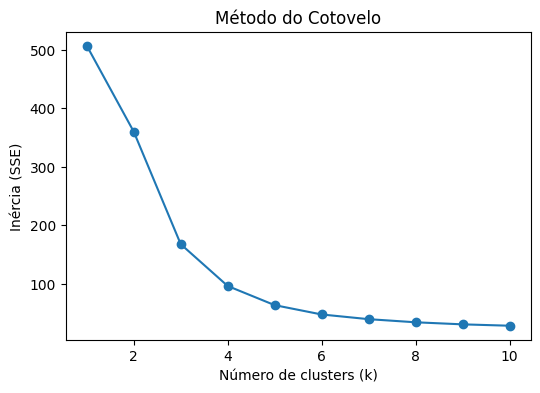

k=2, silhouette=0.488
k=3, silhouette=0.498
k=4, silhouette=0.423
k=5, silhouette=0.422
k=6, silhouette=0.389
k=7, silhouette=0.335
k=8, silhouette=0.281
k=9, silhouette=0.288
k=10, silhouette=0.275


In [28]:
df22 = df2.T

X = df22.values  

inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.figure(figsize=(6,4))
plt.plot(K, inertias, "o-", color="tab:blue")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (SSE)")
plt.title("Método do Cotovelo")
plt.show()

from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(df11.values)

from sklearn.metrics import silhouette_score

for k in range(2, 11):  # silhouette precisa de pelo menos 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}, silhouette={score:.3f}")

In [31]:
df22.head()

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,0.000119,0.040114,0.007017,0.033756,0.040206,0.052763,0.056876,0.059609,0.064532,0.058588,...,-0.027086,-0.036252,-0.042960,-0.044128,-0.044357,-0.044017,-0.046493,-0.042810,-0.043175,-0.042407
1,0.000763,0.006278,-0.019358,-0.020890,-0.023421,-0.018151,-0.010216,-0.008024,-0.001931,0.009036,...,-0.010832,-0.014002,-0.010508,-0.011004,-0.009634,-0.011152,-0.010097,-0.012362,-0.013466,-0.014033
2,0.011364,-0.007171,0.002425,-0.002834,-0.014089,-0.019788,-0.038443,-0.045091,-0.062291,-0.066020,...,0.048408,0.049411,0.060574,0.065928,0.076031,0.076753,0.081314,0.084471,0.086910,0.088379
3,-0.005875,-0.038338,-0.097799,-0.180628,-0.241989,-0.292826,-0.343021,-0.400617,-0.449516,-0.491871,...,-1.235998,-1.249159,-1.265874,-1.285935,-1.301808,-1.312918,-1.321519,-1.333560,-1.343678,-1.357149
4,0.011933,-0.046237,-0.012276,-0.035914,-0.030757,-0.034821,-0.045122,-0.055760,-0.066467,-0.080184,...,-0.068676,-0.065369,-0.058258,-0.052706,-0.048539,-0.044249,-0.040990,-0.036371,-0.033478,-0.028487


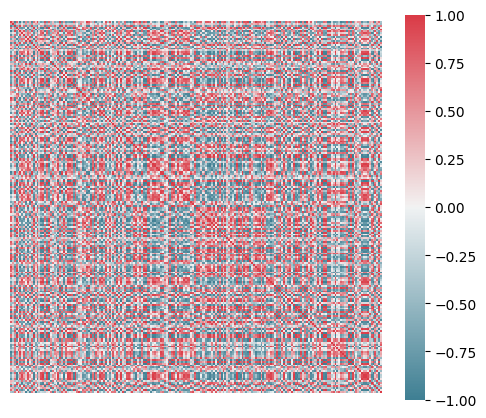

In [34]:
corr = df22.T.corr(method="pearson")
plt.figure(figsize=(6, 5))
sns.heatmap(corr, 
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            vmin=-1, vmax=1, square=True, annot=False,
            xticklabels=False,  # Remove labels do eixo x
            yticklabels=False,  # Remove labels do eixo y
            cbar=True)
    
    
plt.xlabel("")
plt.ylabel("")
    

plt.show()

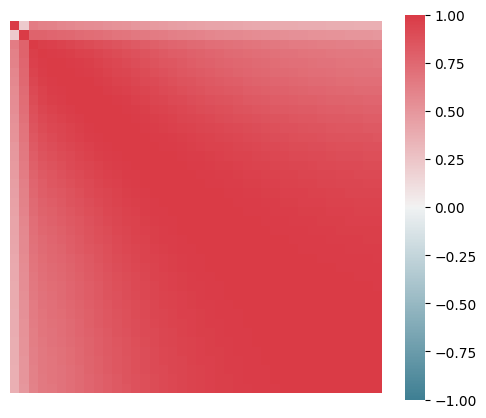

In [33]:
corr = df22.corr(method="pearson")
plt.figure(figsize=(6, 5))
sns.heatmap(corr, 
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            vmin=-1, vmax=1, square=True, annot=False,
            xticklabels=False,  # Remove labels do eixo x
            yticklabels=False,  # Remove labels do eixo y
            cbar=True)
    
    
plt.xlabel("")
plt.ylabel("")
    

plt.show()

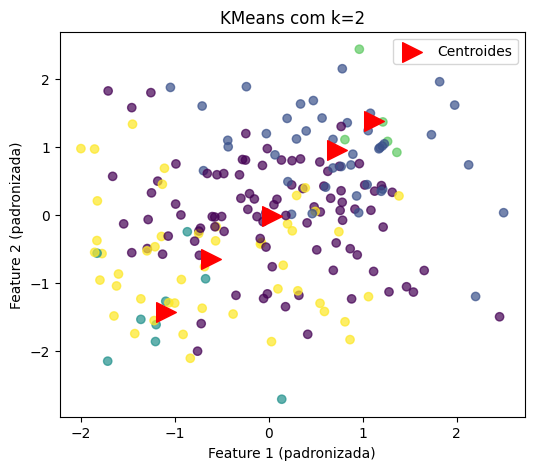

In [29]:
# Supondo que 'df' seja o seu DataFrame numérico
X = df22.values  

# Padronizar (boa prática para KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 2. Rodar o KMeans ===
nc = 5

kmeans = KMeans(n_clusters=nc, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_scaled)

# Adicionar os rótulos dos clusters ao DataFrame original
df11["cluster"] = labels

# === 3. Visualização (2 primeiras dimensões) ===
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap="viridis", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c="red", marker=">", s=200, label="Centroides")
plt.xlabel("Feature 1 (padronizada)")
plt.ylabel("Feature 2 (padronizada)")
plt.title("KMeans com k=2")
plt.legend()
plt.show()

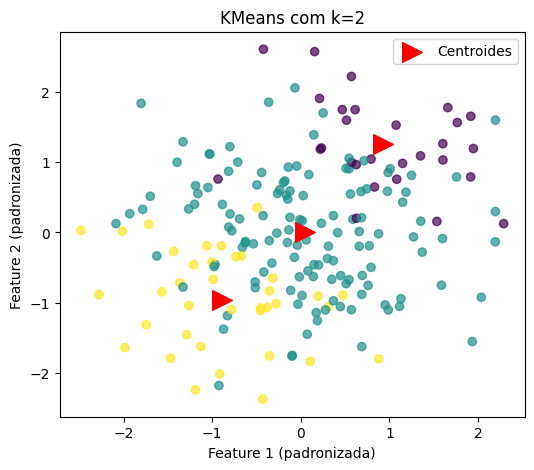

In [23]:
# Supondo que 'df' seja o seu DataFrame numérico
X = df11.values  

# Padronizar (boa prática para KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 2. Rodar o KMeans ===
nc = 3

kmeans = KMeans(n_clusters=nc, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_scaled)

# Adicionar os rótulos dos clusters ao DataFrame original
df11["cluster"] = labels

# === 3. Visualização (2 primeiras dimensões) ===
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap="viridis", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c="red", marker=">", s=200, label="Centroides")
plt.xlabel("Feature 1 (padronizada)")
plt.ylabel("Feature 2 (padronizada)")
plt.title("KMeans com k=2")
plt.legend()
plt.show()

In [14]:
df11.shape

(196, 41)

In [17]:
df111 = df11.T

In [13]:
df11.head()

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,cluster
0,-0.010001,0.052879,0.010942,0.005931,0.011998,0.023127,0.038643,0.059565,0.072960,0.087641,...,0.017430,0.016626,0.011045,0.008769,0.005223,0.003714,0.004027,0.004949,0.006407,1
1,-0.008626,-0.005614,-0.057191,-0.080078,-0.117788,-0.141342,-0.169308,-0.190568,-0.215061,-0.226079,...,-0.434179,-0.433463,-0.432851,-0.443191,-0.437892,-0.438488,-0.440389,-0.441248,-0.442710,2
2,-0.007623,0.014709,0.027806,-0.014695,0.002982,0.006458,0.025479,0.035338,0.048681,0.059426,...,0.295436,0.296913,0.299460,0.305960,0.301012,0.299613,0.300263,0.301148,0.301977,1
3,-0.011572,0.032690,0.017994,0.020060,0.045945,0.067432,0.082275,0.105203,0.126748,0.145882,...,0.187600,0.188492,0.193633,0.188898,0.191674,0.187545,0.186613,0.184874,0.183996,1
4,-0.003109,-0.075679,-0.065671,-0.095414,-0.117658,-0.141307,-0.163869,-0.189036,-0.204341,-0.214388,...,-0.178313,-0.177927,-0.174963,-0.175254,-0.181330,-0.181639,-0.182577,-0.182319,-0.169366,2


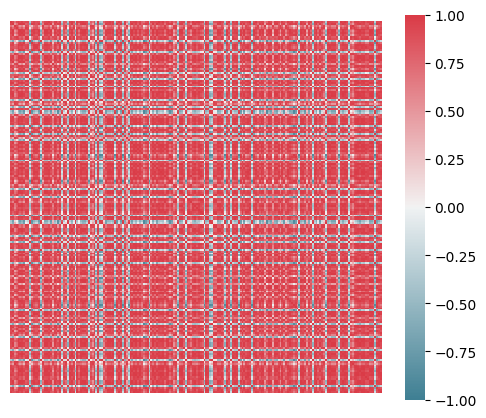

In [18]:
# Calcula a correlação de Pearson
corr = df111.corr(method="pearson")
plt.figure(figsize=(6, 5))
sns.heatmap(corr, 
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            vmin=-1, vmax=1, square=True, annot=False,
            xticklabels=False,  # Remove labels do eixo x
            yticklabels=False,  # Remove labels do eixo y
            cbar=True)
    
    
plt.xlabel("")
plt.ylabel("")
    

plt.show()

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

clusters = sorted(df11["cluster"].unique())

i =  0

for c in clusters:
    print(f"\n=== Cluster {c} ===")
    
    # Filtra os dados do cluster e remove a coluna 'cluster'
    cluster_df = df11[df11["cluster"] == c].drop(columns="cluster")

    print(cluster_df.shape)

    i = i + len(cluster_df)
    print(i)

    
    # Calcula a correlação de Pearson
    corr = cluster_df.corr(method="pearson")
    
    # Máscara para esconder o triângulo superior
    #mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    
    # Cria a figura
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr, 
                cmap=sns.diverging_palette(220, 10, as_cmap=True),
                vmin=-1, vmax=1, square=True, annot=False,
                xticklabels=False,  # Remove labels do eixo x
                yticklabels=False,  # Remove labels do eixo y
                cbar=True)
    
    plt.title(f"Matriz de Correlação - Cluster {c}")
    
    # Remove os labels de eixos, mas mantém ticks (nomes das colunas)
    plt.xlabel("")
    plt.ylabel("")
    

    plt.show()


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
X = StandardScaler().fit_transform(df1.values)

# Testar k de 1 até, por exemplo, 10
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.figure(figsize=(6,4))
plt.plot(K, inertias, "o-", color="tab:blue")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (SSE)")
plt.title("Elbow Method")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):  # silhouette precisa de pelo menos 2 clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k={k}, silhouette={score:.3f}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# === 1. Preparar os dados ===
# Supondo que 'df' seja o seu DataFrame numérico
X = df1.values  

# Padronizar (boa prática para KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 2. Rodar o KMeans ===
nc = 6

kmeans = KMeans(n_clusters=nc, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_scaled)

# Adicionar os rótulos dos clusters ao DataFrame original
df1["cluster"] = labels

# === 3. Visualização (2 primeiras dimensões) ===
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap="viridis", alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c="red", marker=">", s=200, label="Centroides")
plt.xlabel("Feature 1 (padronizada)")
plt.ylabel("Feature 2 (padronizada)")
plt.title("KMeans com k=2")
plt.legend()
plt.show()

In [ ]:
df1.head()

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

clusters = sorted(df1["cluster"].unique())

i =  0

for c in clusters:
    print(f"\n=== Cluster {c} ===")
    
    # Filtra os dados do cluster e remove a coluna 'cluster'
    cluster_df = df1[df1["cluster"] == c].drop(columns="cluster")

    print(cluster_df.shape)

    i = i + len(cluster_df)
    print(i)

    
    # Calcula a correlação de Pearson
    corr = cluster_df.corr(method="pearson")
    
    # Máscara para esconder o triângulo superior
    #mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    
    # Cria a figura
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr, 
                cmap=sns.diverging_palette(220, 10, as_cmap=True),
                vmin=-1, vmax=1, square=True, annot=False,
                xticklabels=False,  # Remove labels do eixo x
                yticklabels=False,  # Remove labels do eixo y
                cbar=True)
    
    plt.title(f"Matriz de Correlação - Cluster {c}")
    
    # Remove os labels de eixos, mas mantém ticks (nomes das colunas)
    plt.xlabel("")
    plt.ylabel("")
    

    plt.show()


NameError: name 'df1' is not defined

In [ ]:
clusters = sorted(df1["cluster"].unique())

# Criar subplots dinamicamente: 1 linha, N clusters
fig, axs = plt.subplots(1, len(clusters), figsize=(6*len(clusters), 6))

if len(clusters) == 1:
    axs = [axs]  # garante que axs seja iterável mesmo com 1 cluster

# Máscara para mostrar apenas metade da matriz
mask = None

for i, c in enumerate(clusters):
    print(f"\n=== Cluster {c} ===")
    
    cluster_df = df1[df1["cluster"] == c].drop(columns="cluster")
    
    # Matriz de correlação de Pearson
    corr = cluster_df.corr(method="pearson")
    
    # Criar máscara só uma vez (com base no tamanho da matriz)
    if mask is None:
        mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    
    # Plotar heatmap
    sns.heatmap(corr, mask=mask,
                cmap=sns.diverging_palette(220, 10, as_cmap=True),
                vmin=-1, vmax=1, square=True, annot=False,
                ax=axs[i], cbar=(i == len(clusters)-1))  # cbar só no último
    
    axs[i].set_title(f"Cluster {c}")
    axs[i].set_xlabel("Variáveis", fontsize=10)
    axs[i].set_ylabel("Variáveis", fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Iterar sobre cada cluster
for c in sorted(df1["cluster"].unique()):
    print(f"\n=== Cluster {c} ===")
    cluster_df = df1[df1["cluster"] == c].drop(columns="cluster")
    
    # Matriz de correlação de Pearson
    corr = cluster_df.corr(method="pearson")
    #print(corr)
    
    # Heatmap para visualizar
    plt.figure(figsize=(6,5))
    sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title(f"Matriz de Correlação (Cluster {c})")
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

df1 = df1.iloc[:, 1:]  
df2 = df2.iloc[:, 1:]
print(df1.

x_pos = df1.iloc[:, 9]  # coluna na posição 9
y_pos = df1.iloc[:, 10]

from scipy.stats import pearsonr

corr, p_value = pearsonr(df1.iloc[:, 9], df1.iloc[:, 10])
print("Correlação de Pearson:", corr)
print("p-valor:", p_value)

# Criar subplots
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

# ===== (a) Correlação positiva =====
ax = axs[0]
ax.scatter(x_pos, y_pos, color="tab:blue", label="(a) Correlação positiva", alpha=0.7)
ax.legend(loc="upper left", frameon=True, fontsize=9)
ax.set_ylabel("y")
ax.tick_params(direction='in', length=4, width=1.0, top=True, bottom=True, left=True, right=True)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

In [ ]:
its   = [40,60,80]
lls   = [8]
tnets = ['rbm']

e1 = []; e2 = []; j1 = []; j2 = []; r1 = []; r2 = []; p1 = []; p2 = []; 

for it in its:
    for ll in lls:
        for tnet in tnets :
            print(ll,',',it)
            trained_params_list              = [];  parameters_list = []; iii = []; 
            tFe = 0;  net = tnet; 
            trained_params_list              = []; parameters_list = [];iii = []; 
            exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
            calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
            g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

            print(it)
            tFe = 1; net = tnet; 
            trained_params_list              = [];  parameters_list = []; iii = []; 
            exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
            calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
            g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

            l = ll; l_info = [];  l_info = upper(tnet);  
            str_nets = '1_' + upper(tnet)
            x_pos  = 0.2 ;  y_pos = 0.94; index = 2

            plot2(e_path1,e_path2,
                  j_out1,r_out1,
                  j_out2,r_out2,
                  l,it,l_info,
                  x_pos, y_pos, str_nets)

            plotpca(paths1, paths2,  0, -1, ll,it, str_nets)
            plotpca3(paths1, paths2,  0, -1, ll,it, str_nets) 

            
            #plot_m_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
            #plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
            #plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

In [ ]:
its  = [40]
ll   = 12
tnet = 'nffnn'

e1 = []; e2 = []; j1 = []; j2 = []; r1 = []; r2 = []; p1 = []; p2 = []; 
for it in its:
    print(ll,',',it)
    trained_params_list              = [];  parameters_list = []; iii = []; 
    tFe = 0;  net = tnet; 
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

    print(it)
    tFe = 1; net = tnet; 
    trained_params_list              = [];  parameters_list = []; iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

    l = ll; l_info = [];  l_info = upper(tnet);  
    str_nets = '1_' + upper(tnet)
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2

    plot2(e_path1,e_path2,
            j_out1,r_out1,
            j_out2,r_out2,
            l,it,l_info,
            x_pos, y_pos, str_nets)
        
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

    plot_distributions(paths1, paths2,  0, -1,ll,it, str_nets)
    plotpca(paths1, paths2,  0, -1, ll,it, str_nets)
    plotpca3(paths1, paths2,  0, -1, ll,it, str_nets) 

    e1.append(e_path1); e2.append(e_path2)
    j1.append(j_out1); j2.append(j_out2)   
    r1.append(r_out1); r2.append(r_out2)           
    p1.append(paths1); p2.append(paths2)

In [ ]:
its  = [20, 40, 60]
ll   = 12
tnet = 'rbm'

e1 = []; e2 = []; j1 = []; j2 = []; r1 = []; r2 = []; p1 = []; p2 = []; 
for it in its:
    print(ll,',',it)
    trained_params_list              = [];  parameters_list = []; iii = []; 
    tFe = 0;  net = tnet; 
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

    print(it)
    tFe = 1; net = tnet; 
    trained_params_list              = [];  parameters_list = []; iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

    l = ll; l_info = [];  l_info = upper(tnet);  
    str_nets = '1_' + upper(tnet)
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2

    plot2(e_path1,e_path2,
            j_out1,r_out1,
            j_out2,r_out2,
            l,it,l_info,
            x_pos, y_pos, str_nets)
        
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

    plot_distributions(paths1, paths2,  0, -1,ll,it, str_nets)
    plotpca(paths1, paths2,  0, -1, ll,it, str_nets)
    plotpca3(paths1, paths2,  0, -1, ll,it, str_nets) 

    e1.append(e_path1); e2.append(e_path2)
    j1.append(j_out1); j2.append(j_out2)   
    r1.append(r_out1); r2.append(r_out2)           
    p1.append(paths1); p2.append(paths2)

In [ ]:
its  = [40, 60]
ll   = 20
tnet = 'rbm'

In [ ]:
e1 = []; e2 = []; j1 = []; j2 = []; r1 = []; r2 = []; p1 = []; p2 = []; 
for it in its:
    print(ll,',',it)
    trained_params_list              = [];  parameters_list = []; iii = []; 
    tFe = 0;  net = tnet; 
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

    print(it)
    tFe = 1; net = tnet; 
    trained_params_list              = [];  parameters_list = []; iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

    l = ll; l_info = [];  l_info = upper(tnet);  
    str_nets = '1_' + upper(tnet)
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2

    plot2(e_path1,e_path2,
            j_out1,r_out1,
            j_out2,r_out2,
            l,it,l_info,
            x_pos, y_pos, str_nets)
        
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

    plot_distributions(paths1, paths2,  0, -1,ll,it, str_nets)
    plotpca(paths1, paths2,  0, -1, ll,it, str_nets)
    plotpca3(paths1, paths2,  0, -1, ll,it, str_nets) 

    e1.append(e_path1); e2.append(e_path2)
    j1.append(j_out1); j2.append(j_out2)   
    r1.append(r_out1); r2.append(r_out2)           
    p1.append(paths1); p2.append(paths2)

In [ ]:
its  = [60, 80, 100]
ll   = 12
tnet = 'nffnn'

In [ ]:
e1 = []; e2 = []; j1 = []; j2 = []; r1 = []; r2 = []; p1 = []; p2 = []; 
for it in its:
    print(ll,',',it)
    trained_params_list              = [];  parameters_list = []; iii = []; 
    tFe = 0;  net = tnet; 
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

    print(it)
    tFe = 1; net = tnet; 
    trained_params_list              = [];  parameters_list = []; iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

    l = ll; l_info = [];  l_info.append(upper(tnet));  l_info.append(upper(tnet)) 
    str_nets = '1_' + upper(tnet)
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2

    plot2(e_path1,e_path2,
            j_out1,r_out1,
            j_out2,r_out2,
            l,it,l_info,
            x_pos, y_pos, str_nets)
        
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

    plot_distributions(paths1, paths2,  0, -1,ll,it, str_nets)
    plotpca(paths1, paths2,  0, -1, ll,it, str_nets)
    plotpca3(paths1, paths2,  0, -1, ll,it, str_nets) 

    e1.append(e_path1); e2.append(e_path2)
    j1.append(j_out1); j2.append(j_out2)   
    r1.append(r_out1); r2.append(r_out2)           
    p1.append(paths1); p2.append(paths2)

In [ ]:
df = pd.read_csv(p2[2][2])
len(df)

In [ ]:
%run 0_config_plot.ipynb
x_pos  = 0.2 ;  y_pos = 0.94; index = 0; tnet = 'NFFNN'
print(tnet)
plot2(e1[index],e2[index],j1[index],r1[index],j2[index],r2[index],
              ll,its[index],tnet,x_pos, y_pos, tnet, True)

In [ ]:
%run 0_config_plot.ipynb
plotpca(p1[0], p2[0], 0, -1, ll, 60, tnet, True)

In [ ]:
%run 0_config_plot.ipynb
plotpca3(p1[0], p2[0], 0, -1, ll, 60, tnet, True)

In [ ]:
%run 0_config_plot.ipynb
index = 1
plotpca3(p1[index], p2[index], 0, -1, ll, 80, tnet, True)

In [ ]:
plot_pca_3d_interactive(p1[1][2], 0, -1, "Regime Ferromagnético")
plot_pca_3d_interactive(p2[2][2], 0, -1, "Regime Antiferromagnético")

In [ ]:
e1,e2,j1,j2,r1,r2,p1,p2,ll,tnet,its  = run(ll,tnet, its)

In [ ]:
e1,e2,j1,j2, r1, r2, p1, p2,ll, tnet, its

In [ ]:
%run 0_config_plot.ipynb
x_pos  = 0.2 ;  y_pos = 0.94;
print(tnet)
plot2(e1[0],e2[0],j1[0],r1[0],j2[0],r2[0],
              ll,its[0],tnet,x_pos, y_pos, tnet, True)

In [ ]:
df = pd.read_csv(p1[0][2])

In [ ]:
len(df)

In [ ]:
%run 0_config_plot.ipynb
plotpca3(p2[0], p2[0], 0, -1, ll, 60, tnet, True)

In [ ]:
%run 0_config_plot.ipynb
plotpca(p1[0], p2[0], 0, -1, ll, 60, tnet, True)

In [ ]:
plot_pca_3d_interactive(p1[0][2], 0, -1, "Regime Ferromagnético")
plot_pca_3d_interactive(p2[0][2], 0, -1, "Regime Antiferromagnético")

In [ ]:
pp1 = p1[0][2]

In [ ]:
df1 = pd.read_csv(pp1)

In [ ]:
288/12

In [ ]:
df1.shape

In [ ]:
df1.head()

In [ ]:
its  = [30,40,50,60,70,80]
ll   = 12
tnet = 'nffnn'

In [ ]:
run(ll,tnet, its)

In [ ]:
its  = [10,20,30]
ll   = 6
tnet = 'nffnn'

run(ll,tnet, its)

In [ ]:
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
plot_pca_3d_interactive(paths1[2], 0, -1, "Regime Ferromagnético")
plot_pca_3d_interactive(paths2[2], 0, -1, "Regime Antiferromagnético")

In [ ]:
paths1

In [ ]:
plotpca(paths1, paths2,  0, -1, ll,it, str_nets)

In [ ]:
df1 = pd.read_csv(paths1[2])

In [ ]:
df1.columns

In [ ]:
for it in [40,50,60,70,80,100,120]:
    print(it)
    ll     = 22; tFe = 0;  net = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

    tFe = 1; net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

    l = ll; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2

    plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

    plot_distributions(paths1, paths2,  0, -1,ll,it, str_nets)
    plotpca(paths1, paths2,  0, -1, ll,it, str_nets)

In [ ]:
for it in [40,50,60,70,80]:
    print(it)
    ll     = 20; tFe = 0;  net = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

    tFe = 1; net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

    l = ll; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2

    plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

    plot_distributions(paths1, paths2,  0, -1,ll,it, str_nets)
    plotdp(paths1, paths2,  0, -1, ll,it, str_nets)

In [ ]:
%run 0_config_plot.ipynb
plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

In [ ]:
for it in [40,50,60,70,80]:
    print(it)
    ll     = 6; tFe = 0;  net = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  

    tFe = 1; net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

    l = ll; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2

    plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)
    plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

    plot_distributions(paths1, paths2,  0, -1,ll,it, str_nets)
    plotdp(paths1, paths2,  0, -1, ll,it, str_nets)

In [ ]:
%run 0_config_plot.ipynb

plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

In [ ]:
%run 0_config_plot.ipynb

plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,0)


In [ ]:
plot_pearson_neurons(paths1, paths2, -1, ll,it, str_nets,1)

In [ ]:
L1     = [12];
it = 50; tFe = 0
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  


tFe = 1
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

In [ ]:
l = L1[0]; l_tp = ['RBM', 'RBM']; l_info =  ['RBM', 'RBM']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb
plot_pearson_neurons(paths1, paths2, -1, l[0],it, str_nets)

In [ ]:
L1     = [20];
it = 40; tFe = 0
net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  


tFe = 1
net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  

In [ ]:
l = L1[0]; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
x_pos  = 0.2 ;  y_pos = 0.94; index = 2

plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb
plot_pearson_neurons(paths1, paths2, -1, L1,it, str_nets)

In [ ]:
plot_distributions(paths1, paths2,  0, -1,L1,it, str_nets)

In [ ]:
plotdp(paths1, paths2,  0, -1, L1,it, str_nets)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [6];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 50; tFe = 0
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 50; tFe = 1
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)


l = L1; l_tp = ['RBM', 'RBM']; l_info =  ['RBM', 'RBM']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)
plot_distributions(paths1, paths2,  0, -1,8)
plotdp(paths1, paths2,  0, -1)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [8];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 50; tFe = 0
net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['NFFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 50; tFe = 1
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)


l = L1; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb

str_nets = '1_NFFNN'

plotdp(paths1, paths2,  0, -1, l[0],it, str_nets)

In [ ]:
%run 0_config_plot.ipynb
plot_distributions(paths1, paths2,  0, -1,l[0],it, str_nets)

In [ ]:
%run 0_config_plot.ipynb
plot_pearson_neurons(paths1, paths2, -1, l[0],it, str_nets)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [8];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 50; tFe = 0
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 50; tFe = 1
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)


l = 8; l_tp = ['RBM', 'RBM']; l_info =  ['RBM', 'RBM']

In [ ]:
l = 8; l_tp = ['RBM', 'RBM']; l_info =  ['RBM', 'RBM']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
plot_distributions(paths1, paths2,  0, -1,8)

In [ ]:
plotdp(paths1, paths2,  0, -1)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [12];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 80; tFe = 0
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 80; tFe = 1
net    = 'rbm';str_nets = '1_RBM'; l_info = ['RBM']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)


In [ ]:
l = 12; l_tp = ['RBM', 'RBM']; l_info =  ['RBM', 'RBM']

In [ ]:
%run 0_config_plot.ipynb
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [12];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 600; tFe = 0
net    = 'ffnn';str_nets = '1_FFNN'; l_info = ['1_FFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 600; tFe = 1
net    = 'ffnn';str_nets = '1_FFNN'; l_info = ['1_FFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb
l = 12; l_tp = ['FFNN', 'FFNN']; l_info =  ['FFNN', 'FFNN']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)

In [ ]:
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
L1     = [12];
%run 0_config_plot.ipynb
%run 0_config_nets.ipynb
it = 300; tFe = 0
net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['1_NFFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy1,e_path1         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy1,j_out1         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy1,r_out1, paths1  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Ferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path1,j_out1, r_out1, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)

it = 300; tFe = 1
net    = 'nffnn';str_nets = '1_NFFNN'; l_info = ['1_NFFNN']
for ll in L1:
    print(ll)
    trained_params_list              = []; parameters_list = [];iii = []; 
    exact_gs_energy2,e_path2         = exac_calc_lanczos_ed(tFe,ll, True)
    calc_j_gs_energy2,j_out2         = jastrow_calc(tFe,ll,it,True)
    g_run_cc_energy2,r_out2, paths2  = run_net (tFe,ll,it,True,1, net)  
    l_tp   = ['Antiferromagnético']; 
    x_pos  = 0.2 ;  y_pos = 0.94; index = 2
    plot1(e_path2,j_out2, r_out2, ll, it,l_info,l_tp,x_pos, y_pos, str_nets)


l = 12; l_tp = ['NFFNN', 'NFFNN']; l_info =  ['NFFNN', 'NFFNN']
plot2(e_path1,e_path2,j_out1,r_out1,j_out2,r_out2,l,it,l_info,l_tp,x_pos, y_pos, str_nets)